# Calibrated Detection Delay Benchmarks (New API)

This notebook calibrates detector thresholds under the null and compares detection delays for four groups of methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gridcp.detector import GridDetector
from gridcp.calibration import (
    calibrate_detector_threshold,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import (
    MeanCUSUM,
    MeanCUSUMUnknownVariance,
    MeanOrVariance,
    Variance,
    MultivariateMeanIdentityCov,
    MultivariateMeanUnknownCov,
    MultivariateMeanOrCovariance,
    RegressionMcScan,
    RegressionDirect,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Global Monte Carlo settings
FALSE_ALARM_PROBABILITY = 0.05
N_PATHS_CALIBRATE = 1000
N_PATHS_EVAL = 1000
N_JOBS = 8


def scalar_normal_sampler(rng, loc=0.0, scale=1.0):
    return rng.normal(loc=loc, scale=scale)


def vector_normal_sampler(rng, mean, scale=1.0):
    return rng.normal(loc=mean, scale=scale)


def regression_sampler(rng, beta, sigma=1.0):
    x = rng.normal(loc=0.0, scale=1.0, size=beta.shape[0])
    y = float(x @ beta + rng.normal(loc=0.0, scale=sigma))
    return np.concatenate(([y], x))


def calibrate_detectors(detectors, stream_len, pre_sampler, pre_kwargs, seed):
    calibrated = {}
    for i, (name, det) in enumerate(detectors.items()):
        threshold = calibrate_detector_threshold(
            detector=det,
            false_alarm_probability=FALSE_ALARM_PROBABILITY,
            n_paths=N_PATHS_CALIBRATE,
            stream_len=stream_len,
            pre_sampler=pre_sampler,
            pre_kwargs=pre_kwargs,
            rng=seed + i,
            parallel=True,
            n_jobs=N_JOBS,
        )
        calibrated[name] = with_calibrated_threshold(det, threshold)
    return calibrated


def delay_summary(alarm_times, changepoint, stream_len):
    delays = alarm_times - changepoint
    delays = delays[delays >= 0]  # Only consider alarms after the changepoint
    return {
        "mean_delay": float(np.mean(delays)),
        "median_delay": float(np.median(delays)),
        "alarm_rate": float(np.mean(alarm_times < stream_len)),
    }


def evaluate_delay_curve(
    detectors,
    stream_len,
    changepoint,
    pre_sampler,
    pre_kwargs,
    post_sampler,
    post_kwargs_builder,
    signal_values,
    seed,
):
    rows = []
    for signal in signal_values:
        post_kwargs = post_kwargs_builder(signal)
        for j, (name, det) in enumerate(detectors.items()):
            alarm_times = mc_alarm_times(
                detector=det,
                n_paths=N_PATHS_EVAL,
                stream_len=stream_len,
                pre_sampler=pre_sampler,
                pre_kwargs=pre_kwargs,
                post_sampler=post_sampler,
                post_kwargs=post_kwargs,
                changepoint=changepoint,
                rng=seed + j,
                parallel=True,
                n_jobs=N_JOBS,
            )
            stats = delay_summary(alarm_times, changepoint, stream_len)
            rows.append(
                {
                    "signal": float(signal),
                    "detector": name,
                    **stats,
                }
            )
    return pd.DataFrame(rows)


def plot_delay_curve(df, x_label, title):
    plt.figure(figsize=(8, 4))
    for name, grp in df.groupby("detector"):
        grp = grp.sort_values("signal")
        plt.plot(grp["signal"], grp["mean_delay"], marker="o", label=name)
    plt.xlabel(x_label)
    plt.ylabel("Mean detection delay (indices)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1) Mean-change setting: calibrate known/unknown variance mean detectors + mean-or-variance

In [ ]:
stream_len_1 = 180
changepoint_1 = stream_len_1 // 2

mean_detectors_raw = {
    "MeanCUSUM (known variance)": GridDetector(MeanCUSUM(n_features=1), threshold=1.0),
    "MeanCUSUMUnknownVariance": GridDetector(
        MeanCUSUMUnknownVariance(n_features=1), threshold=1.0
    ),
    "MeanOrVariance": GridDetector(MeanOrVariance(n_features=1), threshold=1.0),
}

mean_detectors = calibrate_detectors(
    detectors=mean_detectors_raw,
    stream_len=stream_len_1,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    seed=1100,
)

mean_signal_grid = np.linspace(0.0, 1.4, num=8)
mean_delay_df = evaluate_delay_curve(
    detectors=mean_detectors,
    stream_len=stream_len_1,
    changepoint=changepoint_1,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    post_sampler=scalar_normal_sampler,
    post_kwargs_builder=lambda mu: {"loc": float(mu), "scale": 1.0},
    signal_values=mean_signal_grid,
    seed=1200,
)

pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
mean_delay_df.sort_values(["detector", "signal"]).head(20)

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.200,MeanCUSUM (known variance),89.746,90.000,0.063
3,0.400,MeanCUSUM (known variance),88.207,90.000,0.111
6,0.600,MeanCUSUM (known variance),78.918,90.000,0.317
9,0.800,MeanCUSUM (known variance),55.672,52.000,0.732
12,1.000,MeanCUSUM (known variance),31.609,25.000,0.961
15,1.200,MeanCUSUM (known variance),17.787,16.000,1.000
18,1.400,MeanCUSUM (known variance),12.422,11.000,1.000
1,0.200,MeanCUSUMUnknownVariance,89.485,90.000,0.046
4,0.400,MeanCUSUMUnknownVariance,85.944,90.000,0.121
7,0.600,MeanCUSUMUnknownVariance,75.983,90.000,0.358


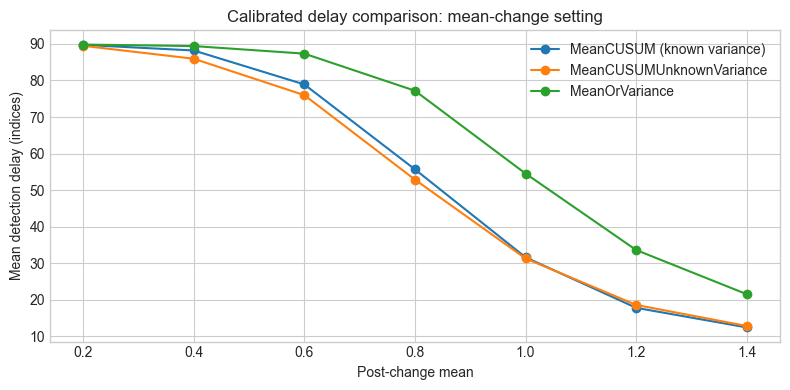

In [4]:
plot_delay_curve(
    mean_delay_df,
    x_label="Post-change mean",
    title="Calibrated delay comparison: mean-change setting",
)

## 2) Variance-change setting: calibrate variance detector + compare to calibrated mean-or-variance detector

In [ ]:
stream_len_2 = stream_len_1
changepoint_2 = stream_len_2 // 2

variance_detector = calibrate_detectors(
    detectors={"Variance": GridDetector(Variance(n_features=1), threshold=1.0)},
    stream_len=stream_len_2,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    seed=2100,
)["Variance"]

variance_comparison_detectors = {
    "Variance": variance_detector,
    "MeanOrVariance (from section 1)": mean_detectors["MeanOrVariance"],
}

post_sigmas = np.array([1.0, 1.25, 1.5, 1.75, 2.0])
variance_delay_df = evaluate_delay_curve(
    detectors=variance_comparison_detectors,
    stream_len=stream_len_2,
    changepoint=changepoint_2,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    post_sampler=scalar_normal_sampler,
    post_kwargs_builder=lambda sigma: {"loc": 0.0, "scale": float(sigma)},
    signal_values=post_sigmas,
    seed=2200,
)

variance_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
1,1.100,MeanOrVariance (from section 1),89.924,90.000,0.062
3,1.250,MeanOrVariance (from section 1),89.788,90.000,0.070
5,1.500,MeanOrVariance (from section 1),86.374,90.000,0.135
7,1.750,MeanOrVariance (from section 1),69.150,90.000,0.421
9,2.000,MeanOrVariance (from section 1),41.823,33.000,0.809
0,1.100,Variance,90.000,90.000,0.040
2,1.250,Variance,89.535,90.000,0.055
4,1.500,Variance,85.971,90.000,0.131
6,1.750,Variance,68.183,90.000,0.454
8,2.000,Variance,41.483,30.000,0.809


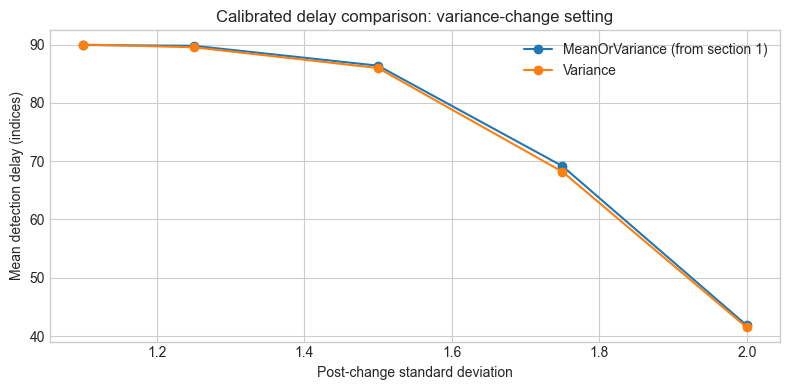

In [6]:
plot_delay_curve(
    variance_delay_df,
    x_label="Post-change standard deviation",
    title="Calibrated delay comparison: variance-change setting",
)

## 3) Multivariate unknown-mean setting: calibrate three methods and compare delays (true sparsity = 1)

In [ ]:
p = 10
stream_len_3 = 100
changepoint_3 = stream_len_3 // 2

mu0 = np.zeros(p, dtype=np.float64)

multivariate_detectors_raw = {
    "MultivariateMeanIdentityCov": GridDetector(
        MultivariateMeanIdentityCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanUnknownCov": GridDetector(
        MultivariateMeanUnknownCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanOrCovariance": GridDetector(
        MultivariateMeanOrCovariance(n_features=p), threshold=1.0
    ),
}

multivariate_detectors = calibrate_detectors(
    detectors=multivariate_detectors_raw,
    stream_len=stream_len_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    seed=3100,
)

# True sparsity = 1: only first coordinate changes.
multivariate_signal_grid = np.array([0.0, 0.2, 0.35, 0.5, 0.7, 0.9, 1.1])


def sparse_mean_kwargs(delta):
    mu = np.zeros(p, dtype=np.float64)
    mu[0] = float(delta)
    return {"mean": mu, "scale": 1.0}


multivariate_delay_df = evaluate_delay_curve(
    detectors=multivariate_detectors,
    stream_len=stream_len_3,
    changepoint=changepoint_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    post_sampler=vector_normal_sampler,
    post_kwargs_builder=sparse_mean_kwargs,
    signal_values=multivariate_signal_grid,
    seed=3200,
)

multivariate_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.200,MultivariateMeanIdentityCov,49.954,50.000,0.048
3,0.350,MultivariateMeanIdentityCov,49.911,50.000,0.049
6,0.500,MultivariateMeanIdentityCov,49.777,50.000,0.050
9,0.700,MultivariateMeanIdentityCov,48.478,50.000,0.110
12,0.900,MultivariateMeanIdentityCov,44.987,50.000,0.293
15,1.100,MultivariateMeanIdentityCov,34.311,35.000,0.699
2,0.200,MultivariateMeanOrCovariance,48.610,50.000,0.065
5,0.350,MultivariateMeanOrCovariance,48.396,50.000,0.078
8,0.500,MultivariateMeanOrCovariance,48.393,50.000,0.087
11,0.700,MultivariateMeanOrCovariance,48.245,50.000,0.096


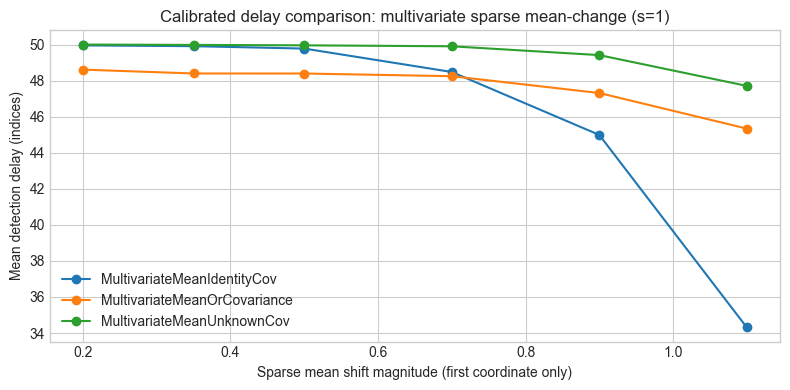

In [8]:
plot_delay_curve(
    multivariate_delay_df,
    x_label="Sparse mean shift magnitude (first coordinate only)",
    title="Calibrated delay comparison: multivariate sparse mean-change (s=1)",
)

## 3.5) Multivariate unknown-mean setting: calibrate three methods and compare delays (true sparsity = p)

In [ ]:
p = 10
stream_len_3 = 100
changepoint_3 = stream_len_3 // 2

mu0 = np.zeros(p, dtype=np.float64)

multivariate_detectors_raw = {
    "MultivariateMeanIdentityCov": GridDetector(
        MultivariateMeanIdentityCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanUnknownCov": GridDetector(
        MultivariateMeanUnknownCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanOrCovariance": GridDetector(
        MultivariateMeanOrCovariance(n_features=p), threshold=1.0
    ),
}

multivariate_detectors = calibrate_detectors(
    detectors=multivariate_detectors_raw,
    stream_len=stream_len_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    seed=3100,
)

# True sparsity = p: all coordinates change.
multivariate_signal_grid = np.array([0.0, 0.2, 0.35, 0.5, 0.7, 0.9, 1.1])


def sparse_mean_kwargs(delta):
    mu = np.ones(p, dtype=np.float64) * delta / np.sqrt(p)
    return {"mean": mu, "scale": 1.0}


multivariate_delay_df = evaluate_delay_curve(
    detectors=multivariate_detectors,
    stream_len=stream_len_3,
    changepoint=changepoint_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    post_sampler=vector_normal_sampler,
    post_kwargs_builder=sparse_mean_kwargs,
    signal_values=multivariate_signal_grid,
    seed=3200,
)

multivariate_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.200,MultivariateMeanIdentityCov,49.954,50.000,0.048
3,0.350,MultivariateMeanIdentityCov,49.860,50.000,0.051
6,0.500,MultivariateMeanIdentityCov,49.788,50.000,0.051
9,0.700,MultivariateMeanIdentityCov,49.704,50.000,0.054
12,0.900,MultivariateMeanIdentityCov,48.940,50.000,0.095
15,1.100,MultivariateMeanIdentityCov,46.183,50.000,0.249
2,0.200,MultivariateMeanOrCovariance,48.762,50.000,0.062
5,0.350,MultivariateMeanOrCovariance,48.551,50.000,0.072
8,0.500,MultivariateMeanOrCovariance,48.260,50.000,0.079
11,0.700,MultivariateMeanOrCovariance,47.787,50.000,0.098


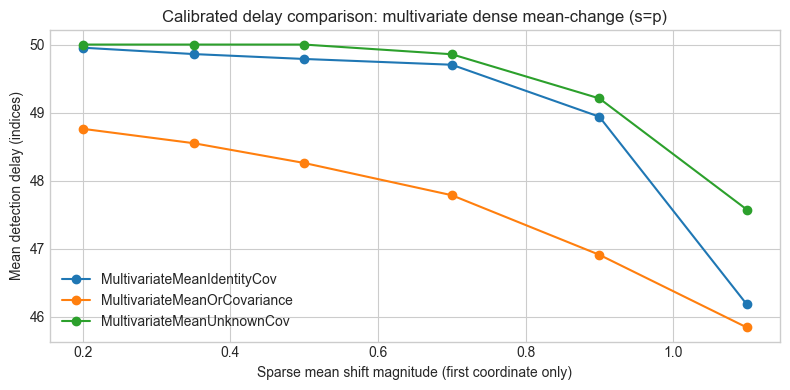

In [10]:
plot_delay_curve(
    multivariate_delay_df,
    x_label="Sparse mean shift magnitude (first coordinate only)",
    title="Calibrated delay comparison: multivariate dense mean-change (s=p)",
)

## 4) Regression-change setting: calibrate McScan and Direct, then compare delays

In [ ]:
q = 8
stream_len_4 = 220
changepoint_4 = stream_len_4 // 2

beta0 = np.zeros(q, dtype=np.float64)

regression_detectors_raw = {
    "RegressionMcScan": GridDetector(RegressionMcScan(n_regressors=q), threshold=1.0),
    "RegressionDirect": GridDetector(RegressionDirect(n_regressors=q), threshold=1.0),
}

regression_detectors = calibrate_detectors(
    detectors=regression_detectors_raw,
    stream_len=stream_len_4,
    pre_sampler=regression_sampler,
    pre_kwargs={"beta": beta0, "sigma": 1.0},
    seed=4100,
)

# Regression signal: one-sparse coefficient shift in beta.
regression_signal_grid = np.array([0.0, 0.25, 0.4, 0.55, 0.75, 1.0])


def regression_post_kwargs(delta):
    beta = np.zeros(q, dtype=np.float64)
    beta[0] = float(delta)
    return {"beta": beta, "sigma": 1.0}


regression_delay_df = evaluate_delay_curve(
    detectors=regression_detectors,
    stream_len=stream_len_4,
    changepoint=changepoint_4,
    pre_sampler=regression_sampler,
    pre_kwargs={"beta": beta0, "sigma": 1.0},
    post_sampler=regression_sampler,
    post_kwargs_builder=regression_post_kwargs,
    signal_values=regression_signal_grid,
    seed=4200,
)

regression_delay_df.sort_values(["detector", "signal"])

KeyboardInterrupt: 

In [ ]:
plot_delay_curve(
    regression_delay_df,
    x_label="Post-change coefficient magnitude (beta_1)",
    title="Calibrated delay comparison: regression-change setting",
)

### 5) Inspect detector state evolution with the calibrated threshold (multivariate identity-covariance mean detector)

In [ ]:
identity_threshold = multivariate_detectors["MultivariateMeanIdentityCov"].threshold
print("Calibrated threshold for MultivariateMeanIdentityCov:", identity_threshold)
identity_det = GridDetector(
    MultivariateMeanIdentityCov(n_features=p),
    threshold=1.0,
)

state = identity_det.init_state()
rng = np.random.default_rng(20260328)

print("calibrated threshold:", identity_threshold)
print("initial state:", state)

# Process a short stream: first null observations, then a sparse mean shift on feature 0.
for t in range(8):
    if t < 4:
        x_t = vector_normal_sampler(rng, mean=np.zeros(p), scale=1.0)
    else:
        shifted_mean = np.zeros(p, dtype=np.float64)
        shifted_mean[0] = 0.8
        x_t = vector_normal_sampler(rng, mean=shifted_mean, scale=1.0)

    state, out = identity_det.update(state, x_t)
    print(
        f"t={t + 1:2d} | alarm={out['alarm']} | max_score={out['max_score']} | "
        f"max_score_index={out['max_score_index']}"
    )

print("\nFinal state summary")
print("n_samples:", state.n_samples)
print("grid:", state.grid)
print("num candidate states:", len(state.candidate_score_states))
print("running score state type:", type(state.running_score_state).__name__)
print("running score state:", state.running_score_state)